In [2]:
# Used Car Price Category Prediction

# Associate Data Scientist Project

# ---

#Business Problem

# A used car dealership wants to automatically classify vehicles into different price categories based on their specifications.

# Instead of predicting the exact selling price, the company wants to classify cars into predefined price categories such as Budget, Mid-Range, Premium, and Luxury.

# This helps:

# - Improve inventory management
# - Recommend vehicles to customers
# - Organize listings efficiently
# - Support pricing decisions

# ---

# ## Machine Learning Problem

# **Classification**

# ---

# ## Dataset

# **Source:** CarDekho Used Cars Dataset

# The dataset contains detailed specifications of used cars including technical specifications, pricing information, ownership details, engine specifications, mileage, fuel type, transmission, and many other vehicle attributes.

# The dataset is uncleaned and requires extensive preprocessing before model development.

# ---

# ## Project Workflow

# 1. Business Understanding
# 2. Dataset Understanding
# 3. Data Profiling
# 4. Data Cleaning
# 5. Exploratory Data Analysis
# 6. Feature Engineering
# 7. Feature Selection
# 8. Model Building
# 9. Model Evaluation
# 10. Business Insights

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [5]:
import os

dataset_paths = [
    'cars_details_merges.csv',
    '/Users/rahulsimhadri/data_analyst/cars_details_merges.csv',
    '/content/cars_details_merges.csv'
]

data_file = None
for path in dataset_paths:
    if os.path.exists(path):
        data_file = path
        break

if data_file:
    df = pd.read_csv(data_file)
else:
    df = pd.read_csv('cars_details_merges.csv')

cars = df.copy()


In [6]:
cars.head()

,position,loc,myear,bt,tt,ft,km,ip,pi,images,imgCount,threesixty,dvn,oem,model,modelId,vid,centralVariantId,variantName,city_x,vlink,price,pu,discountValue,msp,priceSaving,pageNo,utype,views,usedCarId,usedCarSkuId,ucid,sid,tmGaadiStore,emiwidget,transmissionType,dynx_itemid_x,dynx_itemid2_x,dynx_totalvalue_x,leadForm,leadFormCta,offers,compare,brandingIcon,pageType,carType,corporateId,top_features,comfort_features,interior_features,exterior_features,safety_features,Color,Engine Type,Displacement,Max Power,Max Torque,No of Cylinder,Values per Cylinder,Value Configuration,BoreX Stroke,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Seating Capacity,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,No Door Numbers,Cargo Volumn,model_type_new,originalLocation,page_title,compare_car_details,seller_type_new,seating_capacity_new,transmission_type,model_year_new,car_type_new,model_name,model_id_new,oem_name,price_range_segment,dealer_id_new,state,city_id_new,fuel_type,max_engine_capacity_new,transmission_type_new,km_driven,model_new,vehicle_type_new,brand_name,engine_cc,fuel_type_new,car_segment,used_carid,city_name_new,page_type,city_y,engine_capacity_new,body_type_new,owner_type_new,mileage_new,dealer_id,model_year,variant_name,price_segment,dynx_event,dynx_pagetype,dynx_itemid_y,dynx_itemid2_y,dynx_totalvalue_y,brand_new,variant_new,exterior_color,min_engine_capacity_new,owner_type,price_segment_new,template_name_new,page_template,template_Type_new,experiment,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen
0,1,Gomti Nagar,2016,Hatchback,Manual,CNG,"69,162",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,627,Maruti Wagon R LXI CNG,4312,LXI CNG,Lucknow,/buy-used-car-details/used-Maruti-Wagon-R-Lxi-...,₹ 3.70 Lakh,"3,70,000",0,0,NaN,2,Dealer,546,3369178,7111bf25-97af-47f9-867b-40879190d800,3622006,911820426099DD71964BE8369DF166C9,False,"{'title': 'EMI starts', 'cost': '9,184', 'dura...",Manual,3369178,4312,370000,0,NaN,{},True,https://images10.gaadi.com/listing/icons/Certi...,ucr,corporate,13,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Rem...","['Air Conditioner', 'Heater', 'Digital Odomete...","['Adjustable Head Lights', 'Manually Adjustabl...","['Centeral Locking', 'Child Safety Locks', 'Da...",Silver,K10B Engine,998.0,58.16bhp@6200rpm,77Nm@3500rpm,3.0,4.0,DOHC,69 x 72 mm,No,No,3599mm,1495mm,1700mm,2400mm,1295mm,1290mm,960kg,1350kg,5 Speed,FWD,5.0,Power,4.6 metres,Ventilated Disc,Drum,137 kmph,15.9 Seconds,Tubeless Tyres,5.0,180-liters,used,NaN,"Used Maruti Wagon R LXI CNG Car in Lucknow, 20...",NaN,dealer,5.0,manual,2016,used,maruti wagon r,344,maruti,2lakh-5lakh,0,uttar pradesh,320,cng,998.0,manual,69162.0,Maruti Wagon R,car,maruti,500cc-1000cc,cng,Hatchback,3369178.0,lucknow,used-car.detail,lucknow,500cc-1000cc,Hatchback cars,first,26.6 kmpl,0.0,2016.0,maruti wagon r lxi cng,2lakh-5lakh,dynRmktParamsReady,offerdetail,3369178.0,4312.0,370000.0,maruti,maruti wagon r lxi cng,Silver,998.0,first,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
1,2,Borivali West,2015,Hatchback,Manual,CNG,"45,864",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,Maruti Celerio Green VXI,Maruti,Maruti Celerio,955,Maruti Celerio Green VXI,3984,Green VXI,Mumbai,/buy-used-car-details/used-Maruti-Celerio-Gree...,₹ 3.65 Lakh,"3,65,000",0,0,NaN,2,Dealer,670,3364909,c309efc1-efaf-4f82-81ad-dcb38eb36665,3617455,ED2C61CD8482924F87613664BA606F9C,False,"{'title': 'EMI starts', 'cost': '9,060', 'dura...",Manual,3364909,3984,365000,0,NaN,{},True,https://images10.gaadi.com/listing/icons/Certi...,ucr,corporate,13,"['Power Steering', 'Power Windows Front',

In [7]:
cars.shape

(13577, 140)

In [8]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13577 entries, 0 to 13576
Columns: 140 entries, position to Ground Clearance Unladen
dtypes: bool(3), float64(17), int64(21), object(99)
memory usage: 14.2+ MB


In [9]:
cars.describe()

,position,myear,ip,imgCount,modelId,centralVariantId,discountValue,msp,pageNo,views,usedCarId,ucid,dynx_itemid_x,dynx_itemid2_x,dynx_totalvalue_x,leadForm,corporateId,Displacement,No of Cylinder,Values per Cylinder,Seating Capacity,No Door Numbers,originalLocation,compare_car_details,seating_capacity_new,model_year_new,model_id_new,dealer_id_new,city_id_new,max_engine_capacity_new,km_driven,used_carid,dealer_id,model_year,dynx_itemid_y,dynx_itemid2_y,dynx_totalvalue_y,min_engine_capacity_new
count,13577.000000,13577.000000,13577.000000,13577.000000,13577.000000,13577.000000,13577.000000,1.357700e+04,13577.000000,13577.000000,1.357700e+04,1.357700e+04,1.357700e+04,13577.000000,1.357700e+04,13577.000000,13577.000000,13539.000000,13456.000000,13405.000000,13572.000000,13554.000000,0.0,0.0,13562.000000,13577.000000,13577.000000,13577.0,13577.000000,13539.000000,1.357600e+04,1.357600e+04,13576.0,13576.000000,1.357600e+04,13576.000000,1.357600e+04,13538.000000
mean,12.772557,2015.673345,0.013921,13.965530,874.347720,4332.994476,16.719452,8.050379e+01,83.576784,358.231126,3.349702e+06,3.602498e+06,3.349702e+06,4332.994476,1.168918e+06,0.915298,7.788024,1599.085088,3.866974,3.853935,5.308503,4.684964,NaN,NaN,5.312417,2015.673345,335.693452,0.0,202.659129,1599.085088,6.525182e+04,3.349701e+06,0.0,2015.673763,3.349701e+06,4333.130745,1.168710e+06,1598.848205
std,4.540118,3.866095,0.117166,8.614552,959.349213,2673.558139,1037.141880,9.380333e+03,38.444729,561.521861,5.330329e+04,5.381132e+04,5.330329e+04,2673.558139,4.946864e+06,0.278448,2.643160,591.370326,0.684156,0.646595,0.848015,0.493056,NaN,NaN,0.835981,3.866095,244.552413,0.0,213.880004,591.370326,7.049007e+04,5.330513e+04,0.0,3.865931,5.330513e+04,2674.218440,4.946946e+06,590.749458
min,1.000000,1990.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000e+00,2.000000,0.000000,2.123741e+06,2.340004e+06,2.123741e+06,3.000000,1.196300e+04,0.000000,7.000000,0.000000,1.000000,1.000000,0.000000,2.000000,NaN,NaN,2.000000,1990.000000,3.000000,0.0,2.000000,0.000000,1.010000e+02,2.123741e+06,0.0,1990.000000,2.123741e+06,3.000000,1.196300e+04,0.000000
25%,9.000000,2013.000000,0.000000,7.000000,302.000000,2008.000000,0.000000,0.000000e+00,57.000000,83.000000,3.322663e+06,3.575187e+06,3.322663e+06,2008.000000,3.250000e+05,1.000000,7.000000,1197.000000,4.000000,4.000000,5.000000,4.000000,NaN,NaN,5.000000,2013.000000,143.000000,0.0,60.000000,1197.000000,3.175500e+04,3.322650e+06,0.0,2013.000000,3.322650e+06,2008.000000,3.250000e+05,1197.000000
50%,13.000000,2016.000000,0.000000,14.000000,593.000000,4617.000000,0.000000,0.000000e+00,71.000000,201.000000,3.364991e+06,3.617601e+06,3.364991e+06,4617.000000,6.400000e+05,1.000000,7.000000,1493.000000,4.000000,4.000000,5.000000,5.000000,NaN,NaN,5.000000,2016.000000,277.000000,0.0,201.000000,1493.000000,6.000000e+04,3.364992e+06,0.0,2016.000000,3.364992e+06,4617.000000,6.400000e+05,1493.000000
75%,17.000000,2019.000000,0.000000,20.000000,902.000000,6749.000000,0.000000,0.000000e+00,114.000000,424.000000,3.385172e+06,3.638948e+06,3.385172e+06,6749.000000,1.436000e+06,1.000000,7.000000,1968.000000,4.000000,4.000000,5.000000,5.000000,NaN,NaN,5.000000,2019.000000,489.000000,0.0,280.000000,1968.000000,8.900000e+04,3.385174e+06,0.0,2019.000000,3.385174e+06,6750.750000,1.435297e+06,1968.000000
max,20.000000,2023.000000,1.000000,53.000000,3417.000000,9670.000000,94000.000000,1.093000e+06,163.000000,21102.000000,3.399004e+06,3.654045e+06,3.399004e+06,9670.000000,5.500006e+08,1.000000,17.000000,5972.000000,16.000000,48.000000,14.000000,6.000000,NaN,NaN,14.000000,2023.000000,1022.000000,0.0,1721.000000,5972.000000,6.300000e+06,3.399004e+06,0.0,2023.000000,3.399004e+06,9670.000000,5.500006e+08,5972.000000


In [10]:
cars.describe(include="object")

,loc,bt,tt,ft,km,pi,images,dvn,oem,model,vid,variantName,city_x,vlink,price,pu,priceSaving,utype,usedCarSkuId,sid,emiwidget,transmissionType,leadFormCta,offers,brandingIcon,pageType,carType,top_features,comfort_features,interior_features,exterior_features,safety_features,Color,Engine Type,Max Power,Max Torque,Value Configuration,BoreX Stroke,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,Cargo Volumn,model_type_new,page_title,seller_type_new,transmission_type,car_type_new,model_name,oem_name,price_range_segment,state,fuel_type,transmission_type_new,model_new,vehicle_type_new,brand_name,engine_cc,fuel_type_new,car_segment,city_name_new,page_type,city_y,engine_capacity_new,body_type_new,owner_type_new,mileage_new,variant_name,price_segment,dynx_event,dynx_pagetype,brand_new,variant_new,exterior_color,owner_type,price_segment_new,template_name_new,page_template,template_Type_new,experiment,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen
count,10050,13568,13577,13577,13577,13339,13577,13577,13577,13577,13577,13577,13577,13577,13577,13577,1,13577,13577,13577,13577,13577,12427,13577,90,13577,13577,13577,13577,13577,13577,13577,13476,13017,13470,13470,10134,3727,12753,11269,13416,13408,13415,13239,7450,7443,8872,6664,13353,12156,13141,10777,13400,13401,8228,8155,13357,11406,13577,13577,13577,13577,13577,13577,13577,13577,13577,13577,13577,13576,13576,13576,13436,13576,13567,13576,13576,13576,13436,13576,13576,13083,13576,13576,13576,13576,13576,13576,13497,13576,13576,13576,13576,13576,13576,11558,3300,10091,1174
unique,427,11,2,5,7446,13339,13340,2228,37,296,2228,1965,610,13577,1944,2996,1,2,13577,13576,2982,2,1,1,1,2,3,255,1155,371,1168,1266,462,438,748,593,8,168,8,4,404,329,335,264,186,192,605,362,113,22,10,192,33,39,292,308,32,301,1,13577,2,2,1,296,37,5,33,5,2,296,1,37,6,5,11,610,1,610,6,12,6,479,2227,5,1,1,37,2227,462,6,5,4,1,1,1,78,82,17,28
top,Pune City,SUV,Manual,Diesel,"1,20,000",https://images10.gaadi.com/usedcar_image/origi...,[{'img': ''}],Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,Maruti Wagon R LXI CNG,LXI CNG,New Delhi,/used-car-details/used-Porsche-Cayenne-Turbo-S...,₹ 2.50 Lakh,"2,50,000",₹94K Regular Off,Dealer,0ad4ecff-eed6-4964-925d-18c466bdcf50,7B69CA452F143F1D77D71153ADF600A6,{},Manual,View Seller Details,{},https://images10.gaadi.com/listing/icons/Certi...,cls,partner,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Pow...","['Air Conditioner', 'Heater', 'Adjustable Stee...","['Adjustable Head Lights', 'Manually Adjustabl...","['Centeral Locking', 'Child Safety Locks', 'Da...",White,In-Line Engine,67bhp@5500rpm,250Nm@1500-2500rpm,DOHC,73.5 X 88.3 mm,Yes,No,4315mm,1699mm,1466mm,2750mm,1560mm,1290mm,960kg,1350kg,5 Speed,FWD,Power,5.2 metres,Disc,Drum,145 Kmph,16 Seconds,"Tubeless,Radial",475-litres,used,"Used Porsche Cayenne Turbo S Car in Mumbai, 20...",dealer,manual,used,maruti wagon r,maruti,10+lakh,maharashtra,diesel,manual,Maruti Wagon R,car,maruti,1000cc-2000cc,diesel,SUV,new delhi,used-car.detail,new delhi,1000cc-2000cc,SUV cars,first,20 kmpl,maruti wagon r lxi cng,10+lakh,dynRmktParamsReady,offerdetail,maruti,maruti wagon r lxi cng,White,first,10+lakh,used cardetail v2,Used Car > Detail Page,used,control,Direct Injection,16.0:1,16,185mm
freq,539,4298,8579,6648,381,1,238,276,1473,524,276,305,1809,1,284,279,1,10050,1,2,4106,8579,12427,13577,90,12427,12427,3524,554,600,225,207,3924,1365,263,429,8542,268,7274,11175,726,792,723,716,484,669,283,444,6088,8215,10837,857,7928,7990,282,303,8584,607,13577,1,10050,8580,13577,524,1473,4930,3158,6646,8580,524,13576,1473,8877,6646,4297,1809,13576,1809,8877,4297,9107,313,276,4929,13576,13576,1473,276,3930,9107,4929,13486,13576,13576,13576,2186,400,2388,158


In [11]:
cars.columns

Index(['position', 'loc', 'myear', 'bt', 'tt', 'ft', 'km', 'ip', 'pi',
       'images',
       ...
       'owner_type', 'price_segment_new', 'template_name_new', 'page_template',
       'template_Type_new', 'experiment', 'Fuel Suppy System',
       'Compression Ratio', 'Alloy Wheel Size', 'Ground Clearance Unladen'],
      dtype='object', length=140)

In [12]:
cars.isnull().sum()

,0
position,0
loc,3527
myear,0
bt,9
tt,0
...,...
experiment,1
Fuel Suppy System,2019
Compression Ratio,10277
Alloy Wheel Size,3486


In [13]:
(cars.isnull().sum() / len(cars) * 100).sort_values(ascending=False)

,0
compare_car_details,100.000000
originalLocation,100.000000
priceSaving,99.992635
brandingIcon,99.337114
Ground Clearance Unladen,91.353023
...,...
page_title,0.000000
seller_type_new,0.000000
car_type_new,0.000000
model_year_new,0.000000


In [14]:
cars.duplicated().sum()

np.int64(0)

In [15]:
cars.nunique().sort_values()

,0
compare_car_details,0
originalLocation,0
priceSaving,1
offers,1
leadFormCta,1
...,...
usedCarSkuId,13577
page_title,13577
usedCarId,13577
vlink,13577


In [16]:
cars.sample(5, random_state=42)

,position,loc,myear,bt,tt,ft,km,ip,pi,images,imgCount,threesixty,dvn,oem,model,modelId,vid,centralVariantId,variantName,city_x,vlink,price,pu,discountValue,msp,priceSaving,pageNo,utype,views,usedCarId,usedCarSkuId,ucid,sid,tmGaadiStore,emiwidget,transmissionType,dynx_itemid_x,dynx_itemid2_x,dynx_totalvalue_x,leadForm,leadFormCta,offers,compare,brandingIcon,pageType,carType,corporateId,top_features,comfort_features,interior_features,exterior_features,safety_features,Color,Engine Type,Displacement,Max Power,Max Torque,No of Cylinder,Values per Cylinder,Value Configuration,BoreX Stroke,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Seating Capacity,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,No Door Numbers,Cargo Volumn,model_type_new,originalLocation,page_title,compare_car_details,seller_type_new,seating_capacity_new,transmission_type,model_year_new,car_type_new,model_name,model_id_new,oem_name,price_range_segment,dealer_id_new,state,city_id_new,fuel_type,max_engine_capacity_new,transmission_type_new,km_driven,model_new,vehicle_type_new,brand_name,engine_cc,fuel_type_new,car_segment,used_carid,city_name_new,page_type,city_y,engine_capacity_new,body_type_new,owner_type_new,mileage_new,dealer_id,model_year,variant_name,price_segment,dynx_event,dynx_pagetype,dynx_itemid_y,dynx_itemid2_y,dynx_totalvalue_y,brand_new,variant_new,exterior_color,min_engine_capacity_new,owner_type,price_segment_new,template_name_new,page_template,template_Type_new,experiment,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen
749,7,New Delhi G.P.O.,2013,Hatchback,Manual,CNG,"1,25,135",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,20,True,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,627,Maruti Wagon R LXI CNG,4312,LXI CNG,New Delhi,/used-car-details/used-Maruti-Wagon-R-Lxi-Cng-...,₹ 2.30 Lakh,"2,30,000",0,0,NaN,100,Dealer,65,3379036,a301c787-fa2c-4d81-8f06-2f7750063867,3632338,29F211DFF1B8534D2A98E62FEE9D6415,False,"{'title': 'EMI starts', 'cost': '9,988', 'dura...",Manual,3379036,4312,230000,1,View Seller Details,{},True,NaN,cls,partner,7,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Rem...","['Air Conditioner', 'Heater', 'Digital Odomete...","['Adjustable Head Lights', 'Manually Adjustabl...","['Centeral Locking', 'Child Safety Locks', 'Da...",White,K10B Engine,998.0,58.16bhp@6200rpm,77Nm@3500rpm,3.0,4.0,DOHC,69 x 72 mm,No,No,3599mm,1495mm,1700mm,2400mm,1295mm,1290mm,960kg,1350kg,5 Speed,FWD,5.0,Power,4.6 metres,Ventilated Disc,Drum,137 kmph,15.9 Seconds,Tubeless Tyres,5.0,180-liters,used,NaN,"Used Maruti Wagon R LXI CNG Car in New Delhi, ...",NaN,dealer,5.0,manual,2013,used,maruti wagon r,344,maruti,2lakh-5lakh,0,delhi,49,cng,998.0,manual,125135.0,Maruti Wagon R,car,maruti,500cc-1000cc,cng,Hatchback,3379036.0,new delhi,used-car.detail,new delhi,500cc-1000cc,Hatchback cars,first,26.6 kmpl,0.0,2013.0,maruti wagon r lxi cng,2lakh-5lakh,dynRmktParamsReady,offerdetail,3379036.0,4312.0,230000.0,maruti,maruti wagon r lxi cng,White,998.0,first,2lakh-5lakh,used cardetail v2,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
12181,2,ashok vihar,2019,SUV,Automatic,Petrol,"22,000",0,http://dealeradmin.gaadi.com/user/server/php/f...,[{'img': 'http://dealeradmin.gaadi.com/user/se...,19,False,Jeep Compass 1.4 Limited,Jeep,Jeep Compass,902,Jeep Compass 1.4 Limited,5934,1.4 Limited,New Delhi,/used-car-details/used-Jeep-Compass-1.4-Limite...,₹ 16.95 Lakh,"16,95,000",0,0,NaN,52,Dealer,187,3387575,266ffcb1-bb03-40e9-9ebb-632952c0befa,3641550,CC2F46B3A7293A4C73545DFF7070C0CE,False,"{'title': 'EMI starts', 'cost': '42,071', 'dur...",Automatic,3387575,5934,1695000,1,View Seller Details,{},True,NaN,cls,partner,7,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Pow...","[

In [17]:
cars.columns.to_list()

['position',
 'loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'images',
 'imgCount',
 'threesixty',
 'dvn',
 'oem',
 'model',
 'modelId',
 'vid',
 'centralVariantId',
 'variantName',
 'city_x',
 'vlink',
 'price',
 'pu',
 'discountValue',
 'msp',
 'priceSaving',
 'pageNo',
 'utype',
 'views',
 'usedCarId',
 'usedCarSkuId',
 'ucid',
 'sid',
 'tmGaadiStore',
 'emiwidget',
 'transmissionType',
 'dynx_itemid_x',
 'dynx_itemid2_x',
 'dynx_totalvalue_x',
 'leadForm',
 'leadFormCta',
 'offers',
 'compare',
 'brandingIcon',
 'pageType',
 'carType',
 'corporateId',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive

In [18]:
cars.dtypes.value_counts()

,count
object,99
int64,21
float64,17
bool,3


In [19]:
cars.select_dtypes(include="object").columns.tolist()

['loc',
 'bt',
 'tt',
 'ft',
 'km',
 'pi',
 'images',
 'dvn',
 'oem',
 'model',
 'vid',
 'variantName',
 'city_x',
 'vlink',
 'price',
 'pu',
 'priceSaving',
 'utype',
 'usedCarSkuId',
 'sid',
 'emiwidget',
 'transmissionType',
 'leadFormCta',
 'offers',
 'brandingIcon',
 'pageType',
 'carType',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Max Power',
 'Max Torque',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive Type',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'Cargo Volumn',
 'model_type_new',
 'page_title',
 'seller_type_new',
 'transmission_type',
 'car_type_new',
 'model_name',
 'oem_name',
 'price_range_segment',
 'state',
 'fuel_type',
 'transmission_type_n

In [20]:
cars.select_dtypes(include=["int64", "float64"]).columns.tolist()

['position',
 'myear',
 'ip',
 'imgCount',
 'modelId',
 'centralVariantId',
 'discountValue',
 'msp',
 'pageNo',
 'views',
 'usedCarId',
 'ucid',
 'dynx_itemid_x',
 'dynx_itemid2_x',
 'dynx_totalvalue_x',
 'leadForm',
 'corporateId',
 'Displacement',
 'No of Cylinder',
 'Values per Cylinder',
 'Seating Capacity',
 'No Door Numbers',
 'originalLocation',
 'compare_car_details',
 'seating_capacity_new',
 'model_year_new',
 'model_id_new',
 'dealer_id_new',
 'city_id_new',
 'max_engine_capacity_new',
 'km_driven',
 'used_carid',
 'dealer_id',
 'model_year',
 'dynx_itemid_y',
 'dynx_itemid2_y',
 'dynx_totalvalue_y',
 'min_engine_capacity_new']

In [21]:
cars.select_dtypes(include="bool").columns.tolist()

['threesixty', 'tmGaadiStore', 'compare']

In [22]:
cars[
    [
        "tt",
        "transmissionType",
        "transmission_type",
        "transmission_type_new"
    ]
].head(10)

,tt,transmissionType,transmission_type,transmission_type_new
0,Manual,Manual,manual,manual
1,Manual,Manual,manual,manual
2,Manual,Manual,manual,manual
3,Manual,Manual,manual,manual
4,Manual,Manual,manual,manual
5,Manual,Manual,manual,manual
6,Manual,Manual,manual,manual
7,Manual,Manual,manual,manual
8,Manual,Manual,manual,manual
9,Manual,Manual,manual,manual


In [23]:
cars[
    [
        "ft",
        "fuel_type",
        "fuel_type_new"
    ]
].head(10)

,ft,fuel_type,fuel_type_new
0,CNG,cng,cng
1,CNG,cng,cng
2,CNG,cng,cng
3,CNG,cng,cng
4,CNG,cng,cng
5,CNG,cng,cng
6,CNG,cng,cng
7,CNG,cng,cng
8,CNG,cng,cng
9,CNG,cng,cng


In [24]:
cars[
    [
        "model",
        "model_name",
        "model_new"
    ]
].head(10)

,model,model_name,model_new
0,Maruti Wagon R,maruti wagon r,Maruti Wagon R
1,Maruti Celerio,maruti celerio,Maruti Celerio
2,Honda Amaze,honda amaze,Honda Amaze
3,Maruti Wagon R,maruti wagon r,Maruti Wagon R
4,Maruti Ertiga,maruti ertiga,Maruti Ertiga
5,Maruti Wagon R,maruti wagon r,Maruti Wagon R
6,Maruti Alto,maruti alto,Maruti Alto
7,Hyundai Grand i10,hyundai grand i10,Hyundai Grand i10
8,Maruti Wagon R,maruti wagon r,Maruti Wagon R
9,Maruti Wagon R,maruti wagon r,Maruti Wagon R


In [25]:
cars[
    [
        "city_x",
        "city_y",
        "city_name_new"
    ]
].head(10)

,city_x,city_y,city_name_new
0,Lucknow,lucknow,lucknow
1,Mumbai,mumbai,mumbai
2,New Delhi,new delhi,new delhi
3,New Delhi,new delhi,new delhi
4,Mumbai,mumbai,mumbai
5,New Delhi,new delhi,new delhi
6,New Delhi,new delhi,new delhi
7,New Delhi,new delhi,new delhi
8,Gurgaon,gurgaon,gurgaon
9,New Delhi,new delhi,new delhi


In [26]:
cars[
    [
        "price",
        "price_segment",
        "price_segment_new",
        "price_range_segment"
    ]
].head(10)

,price,price_segment,price_segment_new,price_range_segment
0,₹ 3.70 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
1,₹ 3.65 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
2,₹ 4.21 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
3,₹ 2.40 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
4,₹ 11.75 Lakh,10+lakh,10+lakh,10+lakh
5,₹ 2.50 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
6,₹ 1.45 Lakh,0lakh-2lakh,0lakh-2lakh,0lakh-2lakh
7,₹ 4.65 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh
8,₹ 5.60 Lakh,5lakh-8lakh,5lakh-8lakh,5lakh-8lakh
9,₹ 2.15 Lakh,2lakh-5lakh,2lakh-5lakh,2lakh-5lakh


In [27]:
columns_to_drop = [
    "transmissionType",
    "transmission_type",
    "transmission_type_new",

    "fuel_type",
    "fuel_type_new",

    "model_name",
    "model_new",

    "city_y",
    "city_name_new",

    "price_segment",
    "price_segment_new",
    "price_range_segment"
]

cars.drop(columns=columns_to_drop, inplace=True)

In [28]:
cars.shape

(13577, 128)

In [29]:
cars.columns

Index(['position', 'loc', 'myear', 'bt', 'tt', 'ft', 'km', 'ip', 'pi',
       'images',
       ...
       'min_engine_capacity_new', 'owner_type', 'template_name_new',
       'page_template', 'template_Type_new', 'experiment', 'Fuel Suppy System',
       'Compression Ratio', 'Alloy Wheel Size', 'Ground Clearance Unladen'],
      dtype='object', length=128)

In [30]:
metadata_columns = [
    "position",
    "images",
    "imgCount",
    "vlink",
    "pageNo",
    "views",
    "usedCarId",
    "usedCarSkuId",
    "ucid",
    "sid",
    "dynx_itemid_x",
    "dynx_itemid2_x",
    "dynx_totalvalue_x",
    "dynx_itemid_y",
    "dynx_itemid2_y",
    "dynx_totalvalue_y",
    "leadForm",
    "leadFormCta",
    "offers",
    "brandingIcon",
    "pageType",
    "page_type",
    "dynx_event",
    "dynx_pagetype",
    "corporateId",
    "compare",
    "compare_car_details",
    "page_title",
    "experiment",
    "template_name_new",
    "page_template",
    "template_Type_new",
    "tmGaadiStore",
    "threesixty"
]

cars.drop(columns=metadata_columns, inplace=True, errors="ignore")

In [31]:
cars.shape

(13577, 94)

In [32]:
cars.columns.tolist()

['loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'dvn',
 'oem',
 'model',
 'modelId',
 'vid',
 'centralVariantId',
 'variantName',
 'city_x',
 'price',
 'pu',
 'discountValue',
 'msp',
 'priceSaving',
 'utype',
 'emiwidget',
 'carType',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'model_type_new',
 'originalLocation',
 'seller_type_new',
 'seating_capacity_new',
 'model_year_new',
 'car_type_new',
 'model_id_new',

In [33]:
id_columns = [
    "modelId",
    "model_id_new",
    "vid",
    "centralVariantId",
    "dealer_id",
    "dealer_id_new",
    "city_id_new",
    "used_carid",
    "originalLocation"
]

cars.drop(columns=id_columns, inplace=True, errors="ignore")

In [34]:
cars.shape

(13577, 85)

In [35]:
cars.columns.tolist()

['loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'dvn',
 'oem',
 'model',
 'variantName',
 'city_x',
 'price',
 'pu',
 'discountValue',
 'msp',
 'priceSaving',
 'utype',
 'emiwidget',
 'carType',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'model_type_new',
 'seller_type_new',
 'seating_capacity_new',
 'model_year_new',
 'car_type_new',
 'oem_name',
 'state',
 'max_engine_capacity_new',
 'km_driven',
 'vehicle_typ

In [36]:
duplicate_columns = [
    "oem_name",
    "brand_name",
    "brand_new",

    "variant_name",
    "variantName",
    "variant_new",

    "model_year",
    "model_year_new",

    "engine_capacity_new",
    "max_engine_capacity_new",
    "min_engine_capacity_new",

    "owner_type_new",
    "seating_capacity_new",

    "car_type_new",
    "vehicle_type_new",

    "mileage_new"
]

cars.drop(columns=duplicate_columns, inplace=True, errors="ignore")

In [37]:
cars.shape

(13577, 69)

In [38]:
cars.columns.tolist()

['loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'dvn',
 'oem',
 'model',
 'city_x',
 'price',
 'pu',
 'discountValue',
 'msp',
 'priceSaving',
 'utype',
 'emiwidget',
 'carType',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'model_type_new',
 'seller_type_new',
 'state',
 'km_driven',
 'engine_cc',
 'car_segment',
 'body_type_new',
 'exterior_color',
 'owner_type',
 'Fuel Suppy System',
 'Compression Ratio',
 'All

In [39]:
feature_summary = pd.DataFrame({
    "Data Type": cars.dtypes,
    "Missing Values": cars.isnull().sum(),
    "Missing Percentage": (cars.isnull().sum() / len(cars) * 100).round(2),
    "Unique Values": cars.nunique()
})

feature_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Data Type,Missing Values,Missing Percentage,Unique Values
priceSaving,object,13576,99.99,1
Ground Clearance Unladen,object,12403,91.35,28
Compression Ratio,object,10277,75.69,82
BoreX Stroke,object,9850,72.55,168
Gross Weight,object,6913,50.92,362
Rear Tread,object,6134,45.18,192
Front Tread,object,6127,45.13,186
Acceleration,object,5422,39.94,308
Top Speed,object,5349,39.40,292
Kerb Weight,object,4705,34.65,605


In [40]:
columns_to_drop = [
    "priceSaving",                 # 99.99% missing
    "Ground Clearance Unladen",    # 91.35%
    "model_type_new"               # Only one unique value
]

cars.drop(columns=columns_to_drop, inplace=True)

In [41]:
cars.shape

(13577, 66)

In [42]:
feature_summary = pd.DataFrame({
    "Data Type": cars.dtypes,
    "Missing Values": cars.isnull().sum(),
    "Missing Percentage": (cars.isnull().sum() / len(cars) * 100).round(2),
    "Unique Values": cars.nunique()
}).sort_values(by="Missing Percentage", ascending=False)

feature_summary.head(20)

,Data Type,Missing Values,Missing Percentage,Unique Values
Compression Ratio,object,10277,75.69,82
BoreX Stroke,object,9850,72.55,168
Gross Weight,object,6913,50.92,362
Rear Tread,object,6134,45.18,192
Front Tread,object,6127,45.13,186
Acceleration,object,5422,39.94,308
Top Speed,object,5349,39.40,292
Kerb Weight,object,4705,34.65,605
loc,object,3527,25.98,427
Alloy Wheel Size,object,3486,25.68,17


In [43]:
missing_cols = feature_summary[
    feature_summary["Missing Percentage"] > 0
].index.tolist()

missing_cols

['Compression Ratio',
 'BoreX Stroke',
 'Gross Weight',
 'Rear Tread',
 'Front Tread',
 'Acceleration',
 'Top Speed',
 'Kerb Weight',
 'loc',
 'Alloy Wheel Size',
 'Value Configuration',
 'Turning Radius',
 'Super Charger',
 'Cargo Volumn',
 'Fuel Suppy System',
 'Drive Type',
 'Turbo Charger',
 'Engine Type',
 'Steering Type',
 'Wheel Base',
 'pi',
 'Gear Box',
 'Tyre Type',
 'Rear Brake Type',
 'Front Brake Type',
 'Values per Cylinder',
 'Width',
 'Length',
 'Height',
 'engine_cc',
 'No of Cylinder',
 'Max Torque',
 'Max Power',
 'Color',
 'exterior_color',
 'Displacement',
 'No Door Numbers',
 'bt',
 'car_segment',
 'Seating Capacity',
 'body_type_new',
 'km_driven',
 'owner_type']

In [44]:
cars[missing_cols].dtypes

,0
Compression Ratio,object
BoreX Stroke,object
Gross Weight,object
Rear Tread,object
Front Tread,object
Acceleration,object
Top Speed,object
Kerb Weight,object
loc,object
Alloy Wheel Size,object


In [45]:
numerical_missing = cars.select_dtypes(include=["int64", "float64"]).columns
categorical_missing = cars.select_dtypes(include="object").columns

In [46]:
cars[numerical_missing].isnull().sum()

,0
myear,0
ip,0
discountValue,0
msp,0
Displacement,38
No of Cylinder,121
Values per Cylinder,172
Seating Capacity,5
No Door Numbers,23
km_driven,1


In [47]:
cars[categorical_missing].isnull().sum()

,0
loc,3527
bt,9
tt,0
ft,0
km,0
pi,238
dvn,0
oem,0
model,0
city_x,0


In [48]:
cars[numerical_missing] = cars[numerical_missing].fillna(
    cars[numerical_missing].median()
)

In [49]:
cars[categorical_missing] = cars[categorical_missing].fillna(
    cars[categorical_missing].mode().iloc[0]
)

In [50]:
cars.isnull().sum().sum()

np.int64(0)

In [51]:
numerical_columns = cars.select_dtypes(include=["int64", "float64"]).columns

In [52]:
categorical_columns = cars.select_dtypes(include="object").columns

In [53]:
cars[numerical_columns].isnull().sum()

,0
myear,0
ip,0
discountValue,0
msp,0
Displacement,0
No of Cylinder,0
Values per Cylinder,0
Seating Capacity,0
No Door Numbers,0
km_driven,0


In [54]:
cars[numerical_columns] = cars[numerical_columns].fillna(
    cars[numerical_columns].median()
)

In [55]:
cars[categorical_columns] = cars[categorical_columns].fillna(
    cars[categorical_columns].mode().iloc[0]
)

In [56]:
cars.isnull().sum().sum()

np.int64(0)

In [57]:
cars.dtypes

,0
loc,object
myear,int64
bt,object
tt,object
ft,object
km,object
ip,int64
pi,object
dvn,object
oem,object


In [58]:
cars[["price", "km", "Max Power", "Max Torque"]].head()

,price,km,Max Power,Max Torque
0,₹ 3.70 Lakh,"69,162",58.16bhp@6200rpm,77Nm@3500rpm
1,₹ 3.65 Lakh,"45,864",58.2bhp@6000rpm,78Nm@3500rpm
2,₹ 4.21 Lakh,"81,506",86.7bhp@6000rpm,109Nm@4500rpm
3,₹ 2.40 Lakh,"1,15,893",58.2bhp@6200rpm,77Nm@3500rpm
4,₹ 11.75 Lakh,"18,900",86.63bhp@5500rpm,121.5nm@4200rpm


In [59]:
cars["price"] = (
    cars["price"]
    .str.replace("₹", "", regex=False)
    .str.replace("Lakh", "", regex=False)
    .str.replace("Crore", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

cars["price"] = pd.to_numeric(cars["price"], errors="coerce")

In [60]:
cars["km"] = (
    cars["km"]
    .str.replace(" km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

cars["km"] = pd.to_numeric(cars["km"], errors="coerce")

In [61]:
cars["Max Power"] = (
    cars["Max Power"]
    .str.extract(r"(\d+\.?\d*)")[0]
)

cars["Max Power"] = pd.to_numeric(cars["Max Power"], errors="coerce")

In [62]:
cars["Max Torque"] = (
    cars["Max Torque"]
    .str.extract(r"(\d+\.?\d*)")[0]
)

cars["Max Torque"] = pd.to_numeric(cars["Max Torque"], errors="coerce")

In [63]:
cars[["price", "km", "Max Power", "Max Torque"]].dtypes

,0
price,float64
km,int64
Max Power,float64
Max Torque,float64


In [64]:
cars[["price", "km", "Max Power", "Max Torque"]].head()

,price,km,Max Power,Max Torque
0,3.70,69162,58.16,77.0
1,3.65,45864,58.20,78.0
2,4.21,81506,86.70,109.0
3,2.40,115893,58.20,77.0
4,11.75,18900,86.63,121.5


In [65]:
dimension_columns = [
    "Length",
    "Width",
    "Height",
    "Wheel Base",
    "Front Tread",
    "Rear Tread",
    "Kerb Weight",
    "Gross Weight",
    "Turning Radius",
    "Top Speed",
    "Acceleration",
    "Cargo Volumn",
    "Compression Ratio",
    "Alloy Wheel Size"
]

for col in dimension_columns:
    if col in cars.columns:
        cars[col] = (
            cars[col]
            .astype(str)
            .str.extract(r"(\d+\.?\d*)")[0]
        )
        cars[col] = pd.to_numeric(cars[col], errors="coerce")

In [66]:
cars[dimension_columns].dtypes

,0
Length,int64
Width,int64
Height,int64
Wheel Base,int64
Front Tread,float64
Rear Tread,float64
Kerb Weight,int64
Gross Weight,int64
Turning Radius,float64
Top Speed,float64


In [67]:
cars[dimension_columns].head()

,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Turning Radius,Top Speed,Acceleration,Cargo Volumn,Compression Ratio,Alloy Wheel Size
0,3599,1495,1700,2400,1295.0,1290.0,960,1350,4.6,137.0,15.90,180,16.0,16.0
1,3600,1600,1560,2425,1420.0,1410.0,915,1350,4.7,150.0,15.05,235,11.0,16.0
2,3990,1680,1505,2405,1560.0,1290.0,950,1350,4.5,160.0,15.00,400,16.0,16.0
3,3595,1475,1700,2400,1295.0,1290.0,960,1350,4.6,145.0,16.00,475,16.0,13.0
4,4395,1735,1690,2740,1560.0,1290.0,1250,1820,5.2,145.0,16.00,475,12.0,16.0


In [68]:
cars.isnull().sum().sum()

np.int64(127)

In [69]:
numerical_columns = cars.select_dtypes(include=["int64", "float64"]).columns

cars[numerical_columns] = cars[numerical_columns].fillna(
    cars[numerical_columns].median()
)

In [70]:
cars.isnull().sum().sum()

np.int64(0)

In [71]:
bins = [0, 2, 5, 8, float("inf")]
labels = ["Budget", "Mid", "Premium", "Luxury"]

cars["Price Category"] = pd.cut(
    cars["price"],
    bins=bins,
    labels=labels
)

In [72]:
cars["Price Category"].value_counts()

,count
Price Category,
Luxury,5899
Mid,4092
Premium,2117
Budget,1469


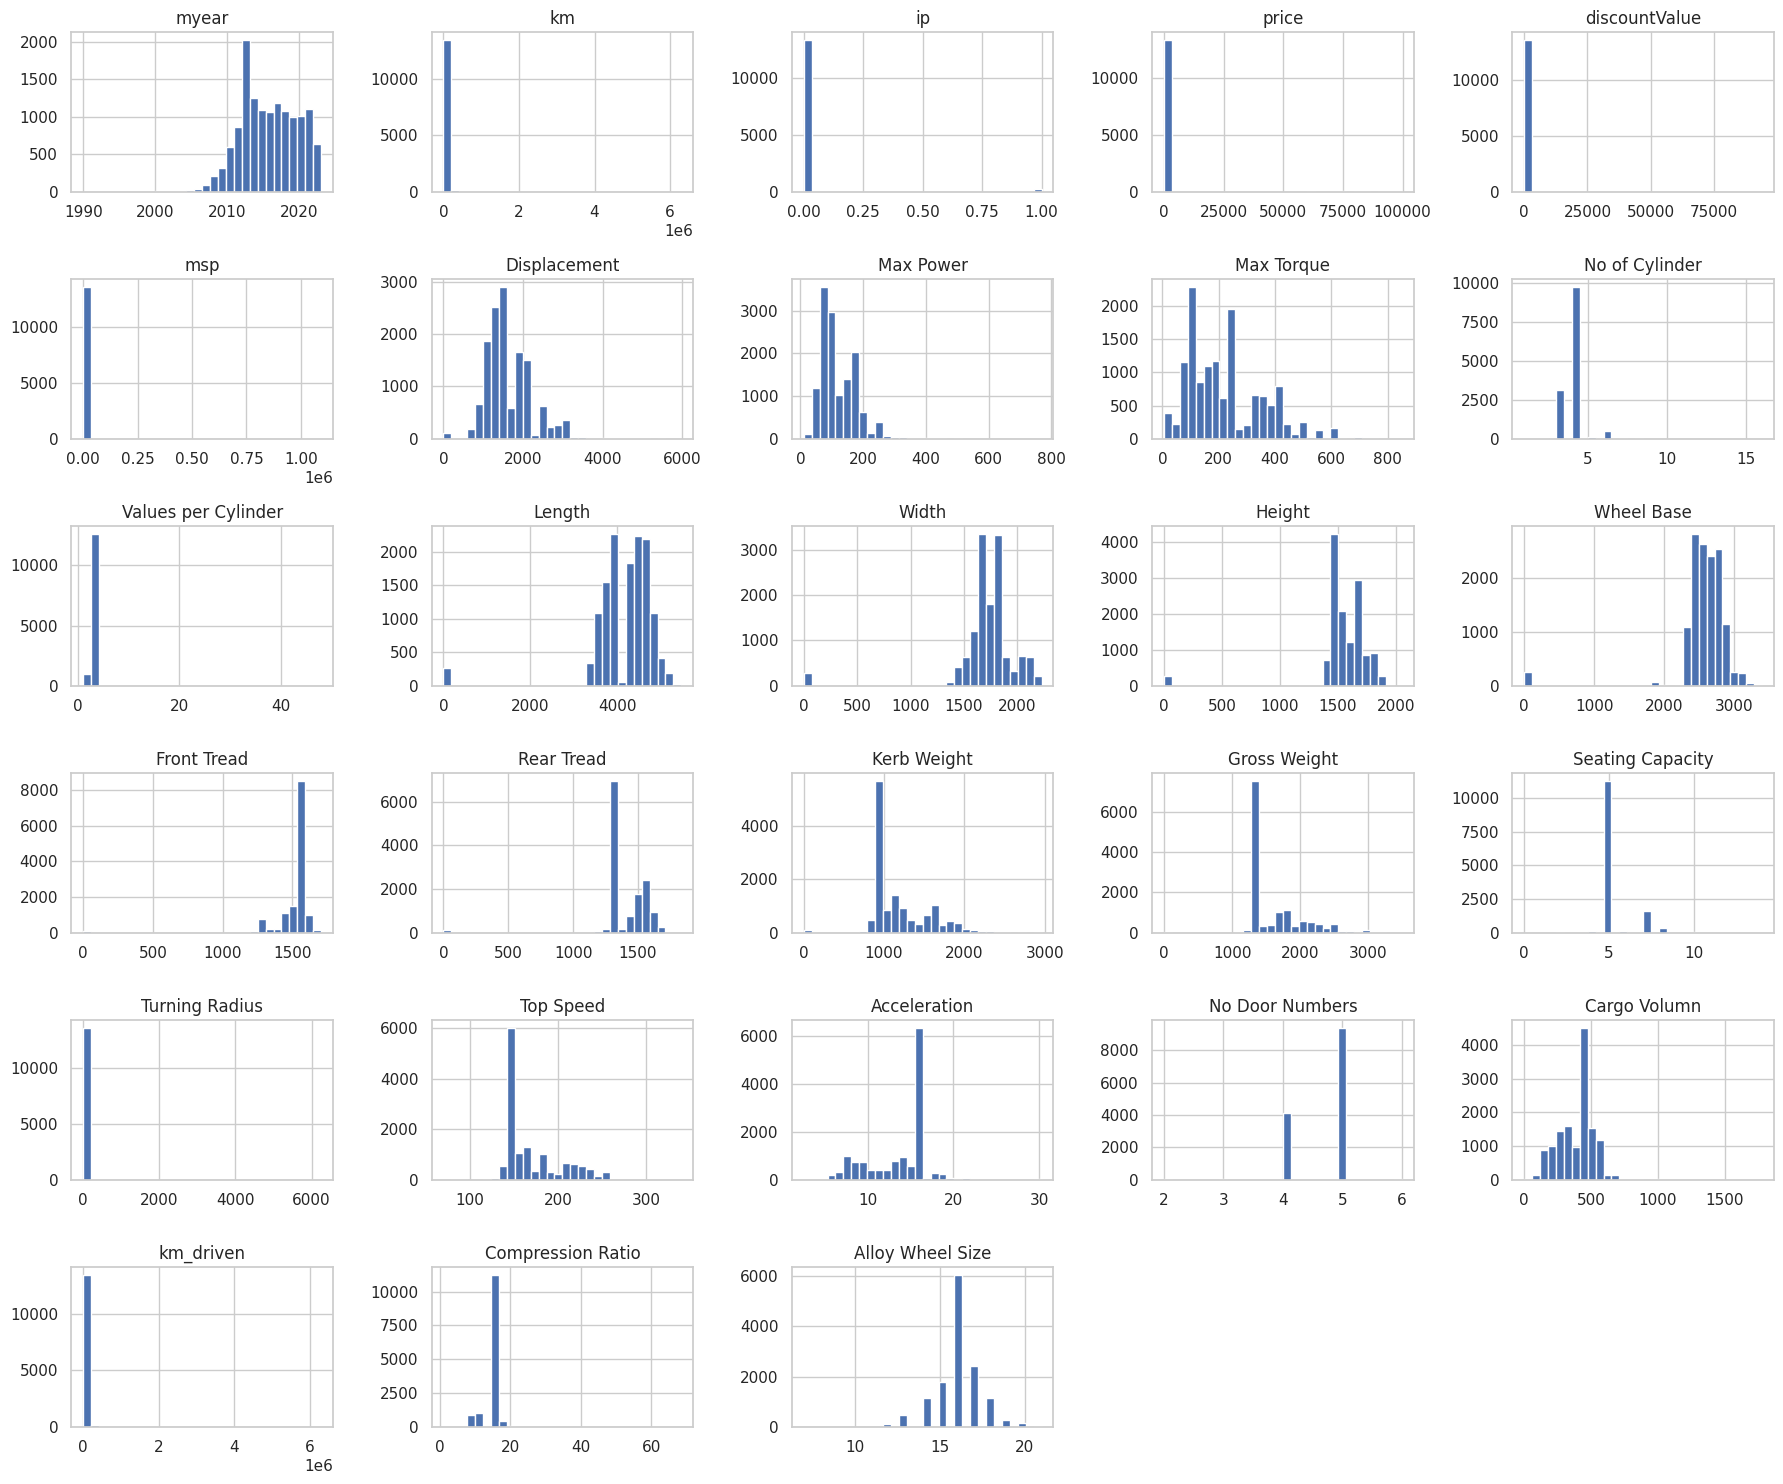

In [73]:
cars.select_dtypes(include=["int64", "float64"]).hist(
    figsize=(18, 15),
    bins=30
)

plt.tight_layout()
plt.show()

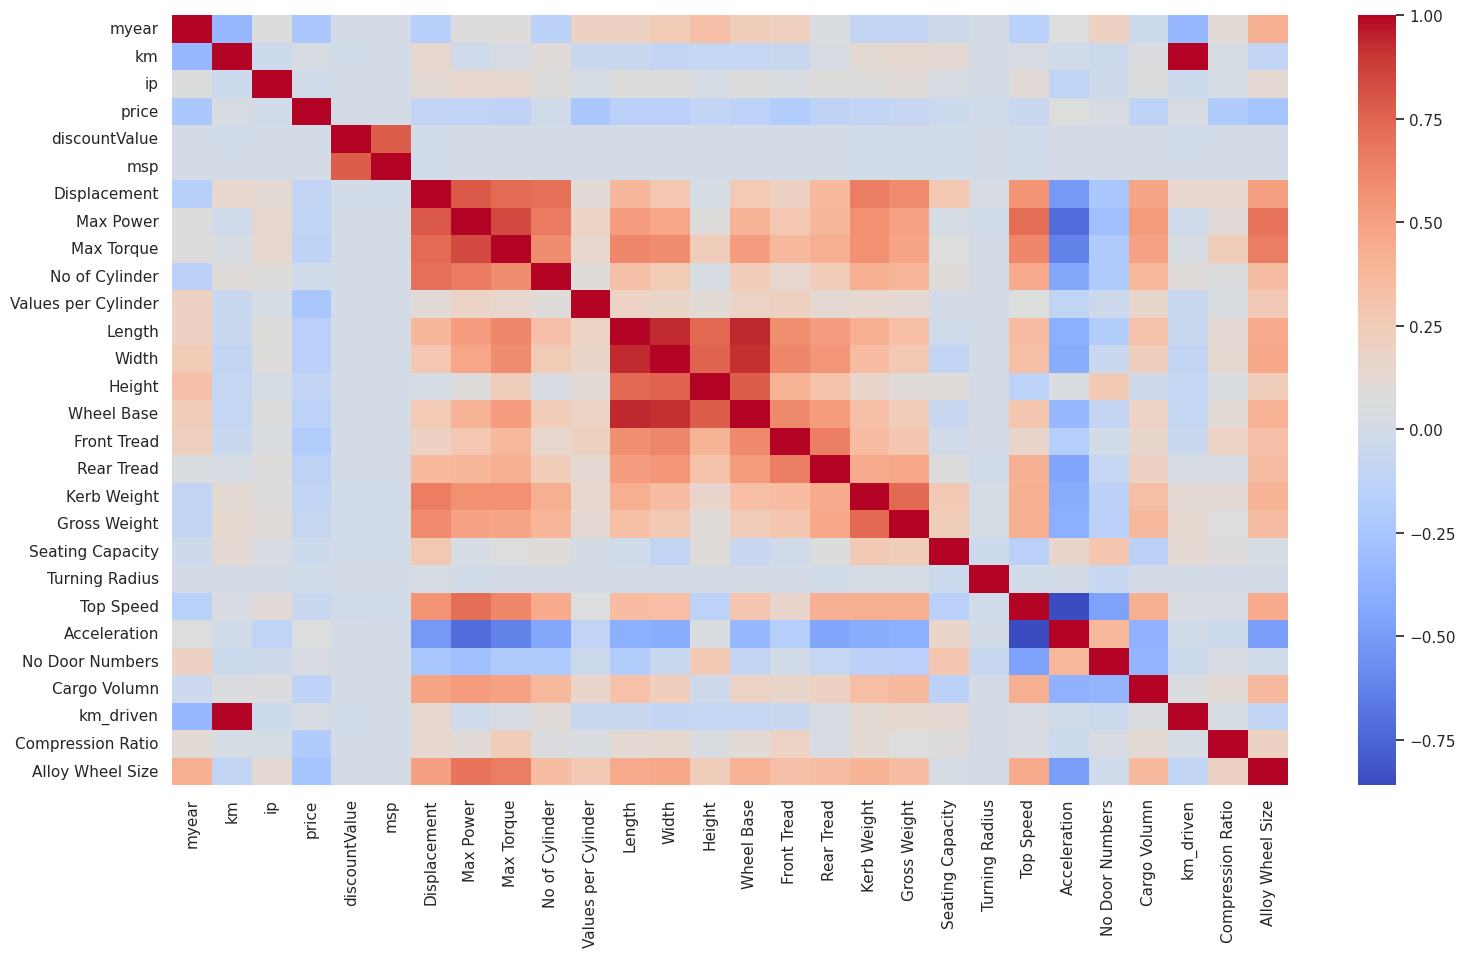

In [74]:
plt.figure(figsize=(18, 10))

sns.heatmap(
    cars.select_dtypes(include=["int64", "float64"]).corr(),
    annot=False,
    cmap="coolwarm"
)

plt.show()

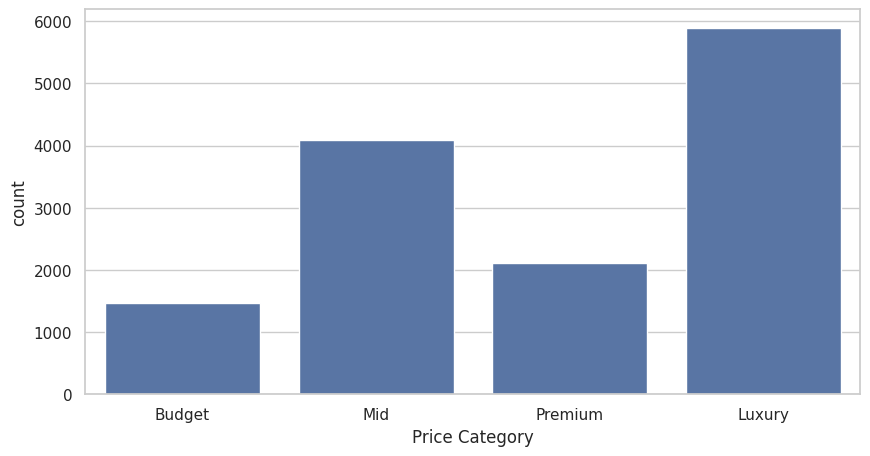

In [75]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=cars,
    x="Price Category"
)

plt.show()

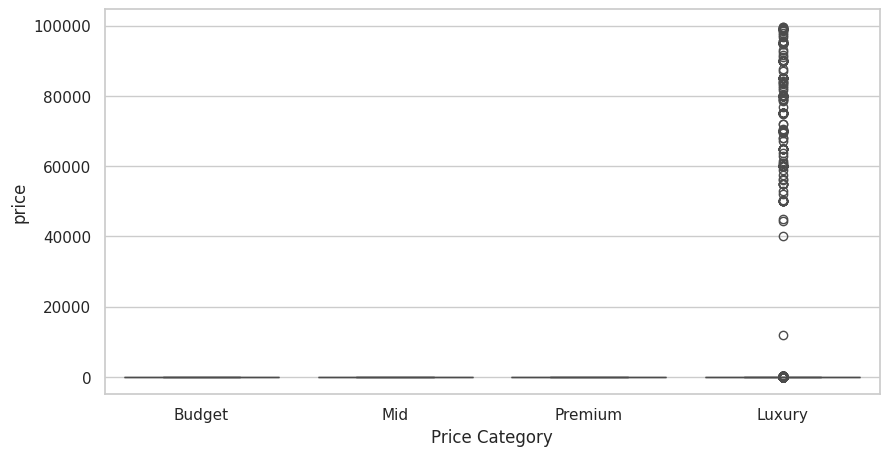

In [76]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=cars,
    x="Price Category",
    y="price"
)

plt.show()

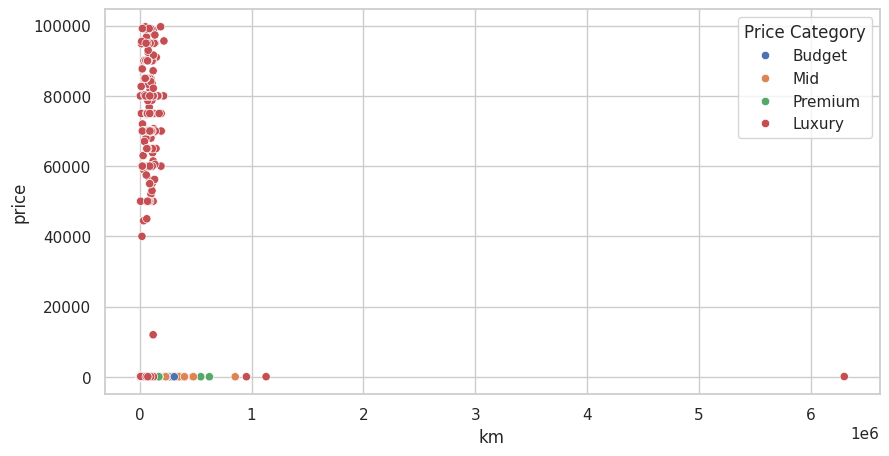

In [77]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=cars,
    x="km",
    y="price",
    hue="Price Category"
)

plt.show()

In [78]:
cars.to_csv("cleaned_cars.csv", index=False)

In [79]:
X = cars.drop(columns=["Price Category", "price"])

y = cars["Price Category"]

In [80]:
X.shape, y.shape

((13577, 65), (13577,))

In [81]:
categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [82]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [83]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [86]:
X_train.shape, X_test.shape

((10861, 65), (2716, 65))

In [87]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7503681885125184

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       294
           1       0.82      0.77      0.79      1180
           2       0.72      0.79      0.75       819
           3       0.56      0.61      0.58       423

    accuracy                           0.75      2716
   macro avg       0.75      0.74      0.74      2716
weighted avg       0.76      0.75      0.75      2716



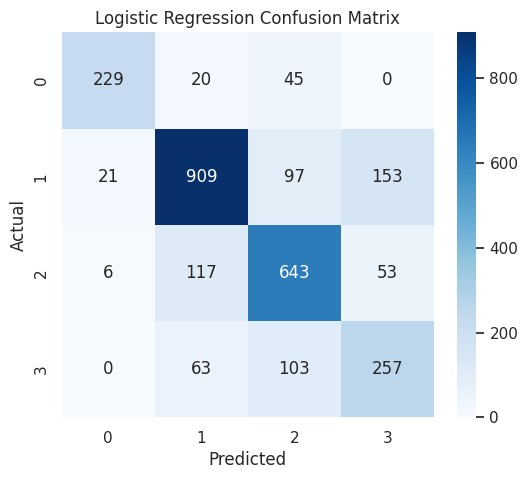

In [89]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [90]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [91]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9959499263622975

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       294
           1       1.00      1.00      1.00      1180
           2       0.99      1.00      1.00       819
           3       1.00      0.99      0.99       423

    accuracy                           1.00      2716
   macro avg       1.00      1.00      1.00      2716
weighted avg       1.00      1.00      1.00      2716



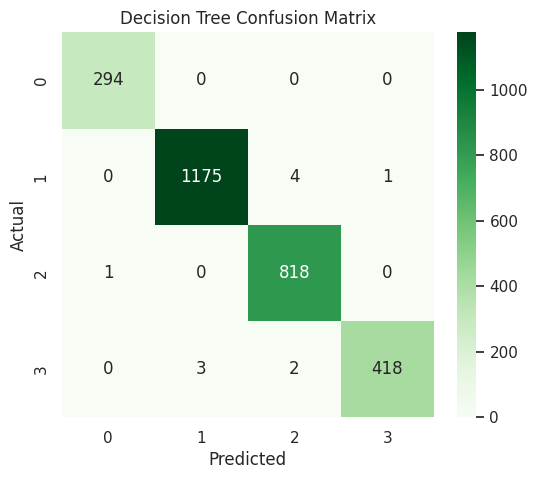

In [92]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [94]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9907952871870398

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       294
           1       0.99      1.00      0.99      1180
           2       0.99      0.99      0.99       819
           3       0.99      0.97      0.98       423

    accuracy                           0.99      2716
   macro avg       0.99      0.99      0.99      2716
weighted avg       0.99      0.99      0.99      2716



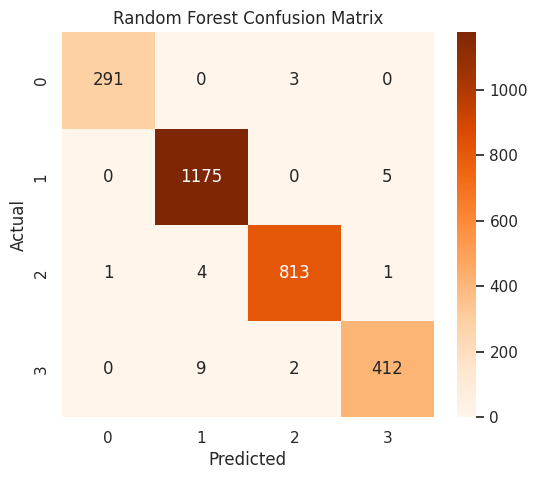

In [95]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [96]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Decision Tree,0.995950
2,Random Forest,0.990795
0,Logistic Regression,0.750368


In [97]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
12,pu,0.283857
26,Max Power,0.063247
1,myear,0.057537
35,Width,0.054934
64,Alloy Wheel Size,0.051206
16,emiwidget,0.051198
37,Wheel Base,0.030293
42,Gear Box,0.029254
27,Max Torque,0.023906
34,Length,0.022326


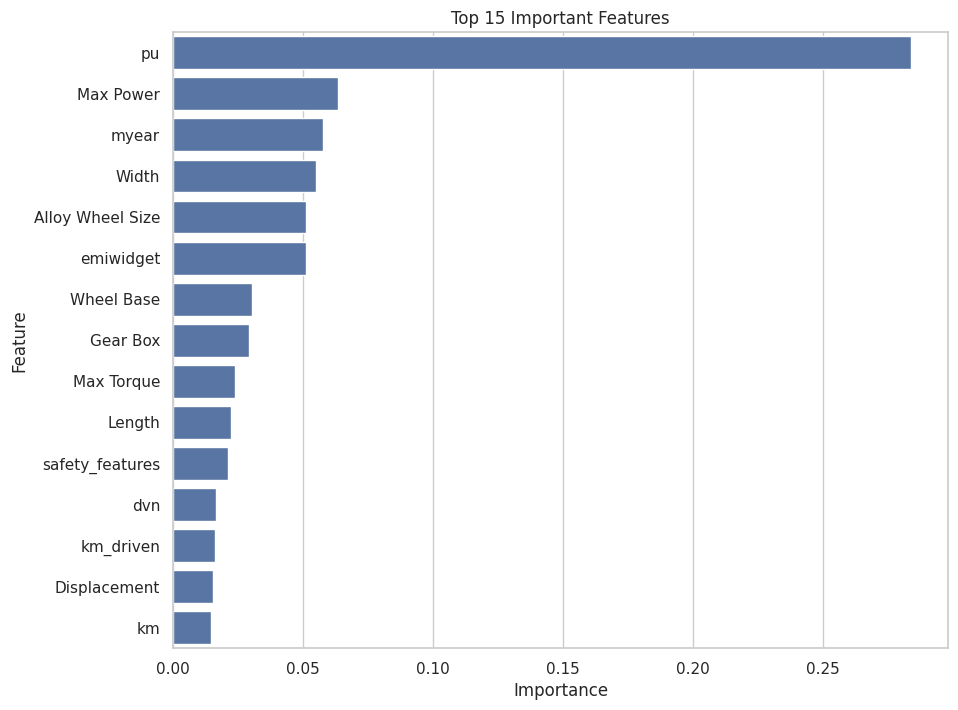

In [98]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [99]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [100]:
X.columns.tolist()

['loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'dvn',
 'oem',
 'model',
 'city_x',
 'pu',
 'discountValue',
 'msp',
 'utype',
 'emiwidget',
 'carType',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'seller_type_new',
 'state',
 'km_driven',
 'engine_cc',
 'car_segment',
 'body_type_new',
 'exterior_color',
 'owner_type',
 'Fuel Suppy System',
 'Compression Ratio',
 'Alloy Wheel Size']

In [101]:
cars["pu"].value_counts().head(10)

,count
pu,
"2,50,000",279
"3,50,000",273
"3,00,000",264
"2,00,000",246
"4,00,000",220
"5,00,000",194
"4,50,000",190
"1,50,000",171
"15,00,000",166


In [102]:
cars["ip"].value_counts()

,count
ip,
0,13388
1,189


In [103]:
cars["discountValue"].value_counts()

,count
discountValue,
0,13570
24000,1
6000,1
3000,1
30000,1
94000,1
5000,1
65000,1


In [104]:
cars["emiwidget"].head(10)

,emiwidget
0,"{'title': 'EMI starts', 'cost': '9,184', 'dura..."
1,"{'title': 'EMI starts', 'cost': '9,060', 'dura..."
2,"{'title': 'EMI starts', 'cost': '10,450', 'dur..."
3,"{'title': 'EMI starts', 'cost': '10,422', 'dur..."
4,"{'title': 'EMI starts', 'cost': '29,164', 'dur..."
5,"{'title': 'EMI starts', 'cost': '20,256', 'dur..."
6,{}
7,"{'title': 'EMI starts', 'cost': '11,542', 'dur..."
8,"{'title': 'EMI starts', 'cost': '13,900', 'dur..."
9,{}


In [105]:
X = X.drop(columns=[
    "pu",
    "emiwidget",
    "discountValue",
    "km_driven",
    "exterior_color"
])

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [108]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7562592047128129


In [109]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7978645066273933


In [110]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8387334315169367


In [111]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.838733
1,Decision Tree,0.797865
0,Logistic Regression,0.756259


In [112]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores)
print("Average Accuracy :", cv_scores.mean())

Cross Validation Scores : [0.48821797 0.54050074 0.56279926 0.49060773 0.69760589]
Average Accuracy : 0.5559463190641638


In [113]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy
0,Random Forest,0.838733
1,Decision Tree,0.797865
2,Logistic Regression,0.756259


In [114]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.48821797 0.54050074 0.56279926 0.49060773 0.69760589]
Average Accuracy: 0.5559463190641638


In [115]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,myear,0.086355
23,Max Power,0.071316
59,Alloy Wheel Size,0.056766
32,Width,0.055780
5,km,0.048101
7,pi,0.036163
39,Gear Box,0.034052
19,safety_features,0.032262
11,city_x,0.030223
34,Wheel Base,0.028807


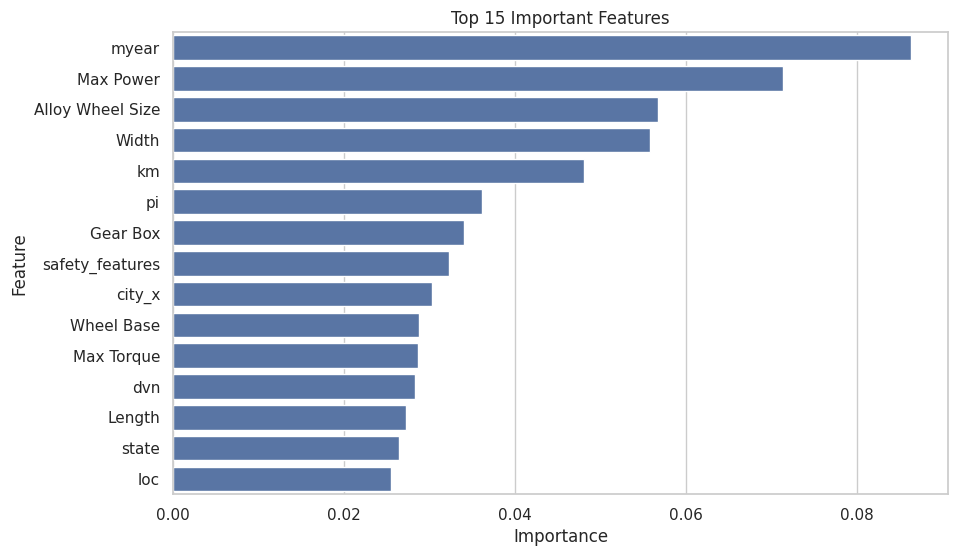

In [116]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

In [117]:
import joblib

joblib.dump(rf, "random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [119]:
# # Conclusion

# - Cleaned a real-world automotive dataset.
# - Handled missing values and duplicate features.
# - Converted text-based features into numerical values.
# - Performed Exploratory Data Analysis.
# - Built Logistic Regression, Decision Tree, and Random Forest classifiers.
# # - Random Forest achieved the best accuracy of **83.87%**.
# - Identified the most influential features affecting vehicle price category.

# ## Business Impact

# The model can automatically classify used vehicles into price categories, helping dealerships improve inventory organization, customer recommendations, and pricing strategies.